<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Multi-Target/Multi_Target_XAI_3_Iterations_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np

In [2]:
path = "/content/drive/MyDrive/Research v2/Research 18.03.2026/GlobalWeatherRepository (3).csv"
df = pd.read_csv(path)

print("Original shape:", df.shape)
df.head()


Original shape: (130003, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

print("Targets:", targets)

Targets: ['air_quality_PM2.5', 'temperature_celsius', 'humidity']


In [4]:

drop_cols_manual = [
    "temperature_fahrenheit",
    "feels_like_fahrenheit",
    "wind_kph",
    "gust_kph",
    "pressure_in",
    "precip_in",
    "visibility_miles",
    "air_quality_us-epa-index",
    "air_quality_gb-defra-index"
]

existing_drop_cols = [col for col in drop_cols_manual if col in df.columns]

df = df.drop(columns=existing_drop_cols)

print("Dropped manually:", existing_drop_cols)
print("Shape after manual drop:", df.shape)

Dropped manually: ['temperature_fahrenheit', 'feels_like_fahrenheit', 'wind_kph', 'gust_kph', 'pressure_in', 'precip_in', 'visibility_miles', 'air_quality_us-epa-index', 'air_quality_gb-defra-index']
Shape after manual drop: (130003, 32)


In [5]:
# Convert timestamp if present
if "last_updated" in df.columns:
    df["last_updated"] = pd.to_datetime(df["last_updated"], errors="coerce")
    df = df.dropna(subset=["last_updated"])
    df = df.sort_values("last_updated").reset_index(drop=True)

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Fill missing numeric values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("Shape after cleaning:", df.shape)

Shape after cleaning: (130003, 32)


In [6]:

from sklearn.preprocessing import LabelEncoder

if "condition_text" in df.columns:
    le_condition = LabelEncoder()
    df["condition_text"] = le_condition.fit_transform(df["condition_text"])

if "wind_direction" in df.columns:
    le_wind = LabelEncoder()
    df["wind_direction"] = le_wind.fit_transform(df["wind_direction"])

print("Categorical encoding completed.")

Categorical encoding completed.


In [7]:
exclude_cols = targets.copy()

if "last_updated" in df.columns:
    exclude_cols.append("last_updated")

candidate_features = [col for col in df.columns if col not in exclude_cols]

print("Number of candidate features:", len(candidate_features))
print(candidate_features)

Number of candidate features: 28
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'condition_text', 'wind_mph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_mph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM10', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [8]:

corr_matrix = df.corr(numeric_only=True)

for target in targets:
    corr_target = corr_matrix[target].drop(target).sort_values(key=np.abs, ascending=False)
    print(f"\nTop correlations for {target}:")
    print(corr_target.head(15))


Top correlations for air_quality_PM2.5:
air_quality_PM10                0.645805
air_quality_Carbon_Monoxide     0.615754
air_quality_Nitrogen_dioxide    0.523122
air_quality_Sulphur_dioxide     0.325861
humidity                       -0.210262
cloud                          -0.178813
visibility_km                  -0.117687
longitude                       0.103413
gust_mph                       -0.062819
condition_text                  0.059368
precip_mm                      -0.052686
temperature_celsius             0.050313
uv_index                        0.048521
wind_mph                       -0.041501
air_quality_Ozone               0.039541
Name: air_quality_PM2.5, dtype: float64

Top correlations for temperature_celsius:
feels_like_celsius              0.983635
uv_index                        0.488923
latitude                       -0.374355
humidity                       -0.343765
pressure_mb                    -0.285187
air_quality_Ozone               0.265507
condition_text 

In [9]:
selected_feature_set = set()

for target in targets:
    corr_target = corr_matrix[target].drop(target)
    useful = corr_target[abs(corr_target) >= 0.10].index.tolist()
    selected_feature_set.update(useful)

selected_feature_set = list(selected_feature_set)

# remove targets if they accidentally came in
selected_feature_set = [col for col in selected_feature_set if col not in targets]

print("Selected candidate features from target correlations:")
print(selected_feature_set)
print("Count:", len(selected_feature_set))

Selected candidate features from target correlations:
['air_quality_PM10', 'latitude', 'air_quality_Carbon_Monoxide', 'feels_like_celsius', 'cloud', 'longitude', 'last_updated_epoch', 'uv_index', 'air_quality_Sulphur_dioxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'condition_text', 'pressure_mb', 'visibility_km', 'precip_mm']
Count: 15


In [10]:
X_selected = df[selected_feature_set].copy()

corr_selected = X_selected.corr(numeric_only=True).abs()

upper = corr_selected.where(
    np.triu(np.ones(corr_selected.shape), k=1).astype(bool)
)

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Highly correlated input features to drop (|corr| > 0.85):")
print(to_drop_corr)

X_final = X_selected.drop(columns=to_drop_corr)
print("Final input shape:", X_final.shape)

Highly correlated input features to drop (|corr| > 0.85):
[]
Final input shape: (130003, 15)


In [11]:

y_final = df[targets].copy()

multi_target_df = pd.concat([X_final, y_final], axis=1)

print("Final cleaned multi-target dataset shape:", multi_target_df.shape)
multi_target_df.head()

Final cleaned multi-target dataset shape: (130003, 18)


,air_quality_PM10,latitude,air_quality_Carbon_Monoxide,feels_like_celsius,cloud,longitude,last_updated_epoch,uv_index,air_quality_Sulphur_dioxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,condition_text,pressure_mb,visibility_km,precip_mm,air_quality_PM2.5,temperature_celsius,humidity
0,7.1,46.60,198.6,16.1,0,-120.49,1715849100,1.0,0.2,62.2,2.5,2,1012.0,16.0,0.00,6.3,16.1,58
1,25.3,14.10,377.2,25.3,37,-87.22,1715849100,1.0,1.4,23.3,3.7,32,1017.0,10.0,0.28,19.0,23.0,78
2,28.1,13.71,460.6,30.2,50,-89.20,1715849100,1.0,7.5,5.9,7.7,23,1010.0,10.0,0.30,20.4,26.0,94
3,178.1,14.62,2243.0,20.0,100,-90.53,1715849100,1.0,19.3,0.4,35.0,19,1019.0,5.0,0.09,132.0,20.0,88
4,32.1,17.25,307.1,29.6,94,-88.77,1715849100,1.0,0.2,34.0,0.3,30,1007.0,10.0,0.00,7.7,26.0,89


In [12]:
multi_target_df.to_csv("cleaned_multi_target_dataset.csv", index=False)

from google.colab import files
files.download("cleaned_multi_target_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
split_index = int(0.8 * len(multi_target_df))

train_df = multi_target_df.iloc[:split_index].copy()
test_df = multi_target_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (104002, 18)
Test shape : (26001, 18)


In [14]:

n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34320, 18)
Iteration 2 shape: (34321, 18)
Iteration 3 shape: (35361, 18)


In [15]:

final_features = [col for col in multi_target_df.columns if col not in targets]

print("Final features used for multi-target model:")
print(final_features)
print("Feature count:", len(final_features))

def get_xy(data):
    X = data[final_features]
    y = data[targets]
    return X, y

X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)
X_test, y_test = get_xy(test_df)

print(X1.shape, y1.shape)
print(X2.shape, y2.shape)
print(X3.shape, y3.shape)
print(X_test.shape, y_test.shape)

Final features used for multi-target model:
['air_quality_PM10', 'latitude', 'air_quality_Carbon_Monoxide', 'feels_like_celsius', 'cloud', 'longitude', 'last_updated_epoch', 'uv_index', 'air_quality_Sulphur_dioxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'condition_text', 'pressure_mb', 'visibility_km', 'precip_mm']
Feature count: 15
(34320, 15) (34320, 3)
(34321, 15) (34321, 3)
(35361, 15) (35361, 3)
(26001, 15) (26001, 3)


In [16]:

for col in targets:
    multi_target_df[f"{col}_lag1"] = multi_target_df[col].shift(1)
    multi_target_df[f"{col}_lag2"] = multi_target_df[col].shift(2)

multi_target_df = multi_target_df.dropna().reset_index(drop=True)

print("Shape after adding target lag features:", multi_target_df.shape)
multi_target_df.head()

Shape after adding target lag features: (130001, 24)


,air_quality_PM10,latitude,air_quality_Carbon_Monoxide,feels_like_celsius,cloud,longitude,last_updated_epoch,uv_index,air_quality_Sulphur_dioxide,air_quality_Ozone,...,precip_mm,air_quality_PM2.5,temperature_celsius,humidity,air_quality_PM2.5_lag1,air_quality_PM2.5_lag2,temperature_celsius_lag1,temperature_celsius_lag2,humidity_lag1,humidity_lag2
0,28.1,13.71,460.6,30.2,50,-89.20,1715849100,1.0,7.5,5.9,...,0.30,20.4,26.0,94,19.0,6.3,23.0,16.1,78.0,58.0
1,178.1,14.62,2243.0,20.0,100,-90.53,1715849100,1.0,19.3,0.4,...,0.09,132.0,20.0,88,20.4,19.0,26.0,23.0,94.0,78.0
2,32.1,17.25,307.1,29.6,94,-88.77,1715849100,1.0,0.2,34.0,...,0.00,7.7,26.0,89,132.0,20.4,20.0,26.0,88.0,94.0
3,14.7,12.15,500.7,30.6,75,-86.27,1715849100,1.0,11.4,14.3,...,0.01,11.7,27.2,80,7.7,132.0,26.0,20.0,89.0,88.0
4,23.3,9.97,1161.6,21.0,75,-84.08,1715849100,1.0,6.6,0.0,...,0.17,21.7,21.0,100,11.7,7.7,27.2,26.0,80.0,89.0


In [17]:

split_index = int(0.8 * len(multi_target_df))

train_df = multi_target_df.iloc[:split_index].copy()
test_df = multi_target_df.iloc[split_index:].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (104000, 24)
Test shape : (26001, 24)


In [18]:
n_train = len(train_df)

iter1 = train_df.iloc[:int(0.33 * n_train)].copy()
iter2 = train_df.iloc[int(0.33 * n_train):int(0.66 * n_train)].copy()
iter3 = train_df.iloc[int(0.66 * n_train):].copy()

print("Iteration 1 shape:", iter1.shape)
print("Iteration 2 shape:", iter2.shape)
print("Iteration 3 shape:", iter3.shape)

Iteration 1 shape: (34320, 24)
Iteration 2 shape: (34320, 24)
Iteration 3 shape: (35360, 24)


In [19]:

final_features = [col for col in multi_target_df.columns if col not in targets]

print("Final features used for multi-target model:")
print(final_features)
print("Feature count:", len(final_features))

def get_xy(data):
    X = data[final_features]
    y = data[targets]
    return X, y

X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)
X_test, y_test = get_xy(test_df)

print(X1.shape, y1.shape)
print(X2.shape, y2.shape)
print(X3.shape, y3.shape)
print(X_test.shape, y_test.shape)

Final features used for multi-target model:
['air_quality_PM10', 'latitude', 'air_quality_Carbon_Monoxide', 'feels_like_celsius', 'cloud', 'longitude', 'last_updated_epoch', 'uv_index', 'air_quality_Sulphur_dioxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'condition_text', 'pressure_mb', 'visibility_km', 'precip_mm', 'air_quality_PM2.5_lag1', 'air_quality_PM2.5_lag2', 'temperature_celsius_lag1', 'temperature_celsius_lag2', 'humidity_lag1', 'humidity_lag2']
Feature count: 21
(34320, 21) (34320, 3)
(34320, 21) (34320, 3)
(35360, 21) (35360, 3)
(26001, 21) (26001, 3)


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

In [21]:
def calculate_metrics_per_target(y_true, y_pred, target_names):
    rows = []

    for i, target in enumerate(target_names):
        mse = mean_squared_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])
        acc = r2 * 100

        rows.append([target, mse, rmse, mae, r2, acc])

    return pd.DataFrame(
        rows,
        columns=["Target", "MSE", "RMSE", "MAE", "R2", "Accuracy (%)"]
    ).round(3)

In [22]:
def get_xy(data):
    X = data[final_features]
    y = data[targets]
    return X, y

X1, y1 = get_xy(iter1)
X2, y2 = get_xy(iter2)
X3, y3 = get_xy(iter3)
X_test, y_test = get_xy(test_df)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))

# Iteration 1
model.fit(X1, y1)
pred1 = model.predict(X1)

# Iteration 2
model.fit(pd.concat([X1, X2]), pd.concat([y1, y2]))
pred2 = model.predict(X2)

# Iteration 3
model.fit(pd.concat([X1, X2, X3]), pd.concat([y1, y2, y3]))
pred3 = model.predict(X3)

# Test
test_pred = model.predict(X_test)

rf_iter = pd.concat([
    calculate_metrics_per_target(y1, pred1, targets).assign(Iteration="Iteration 1"),
    calculate_metrics_per_target(y2, pred2, targets).assign(Iteration="Iteration 2"),
    calculate_metrics_per_target(y3, pred3, targets).assign(Iteration="Iteration 3"),
])

rf_iter["Model"] = "Random Forest"

rf_test = calculate_metrics_per_target(y_test, test_pred, targets)
rf_test["Model"] = "Random Forest"

In [24]:
all_iterations = pd.concat([
    rf_iter
], ignore_index=True)

all_iterations

,Target,MSE,RMSE,MAE,R2,Accuracy (%),Iteration,Model
0,air_quality_PM2.5,4.698,2.167,0.766,0.998,99.784,Iteration 1,Random Forest
1,temperature_celsius,0.058,0.242,0.149,0.999,99.894,Iteration 1,Random Forest
2,humidity,9.103,3.017,2.175,0.985,98.532,Iteration 1,Random Forest
3,air_quality_PM2.5,9.352,3.058,1.238,0.994,99.377,Iteration 2,Random Forest
4,temperature_celsius,0.069,0.263,0.164,0.999,99.934,Iteration 2,Random Forest
5,humidity,10.920,3.305,2.378,0.980,98.038,Iteration 2,Random Forest
6,air_quality_PM2.5,3.616,1.902,0.904,0.996,99.648,Iteration 3,Random Forest
7,temperature_celsius,0.064,0.253,0.144,0.999,99.882,Iteration 3,Random Forest
8,humidity,9.279,3.046,2.209,0.983,98.345,Iteration 3,Random Forest


In [25]:
all_test = pd.concat([
    rf_test
], ignore_index=True)

all_test

,Target,MSE,RMSE,MAE,R2,Accuracy (%),Model
0,air_quality_PM2.5,47.892,6.920,2.981,0.920,92.001,Random Forest
1,temperature_celsius,0.854,0.924,0.580,0.993,99.313,Random Forest
2,humidity,173.138,13.158,9.300,0.639,63.883,Random Forest


In [26]:

rmse_table = all_test.pivot(index="Target", columns="Model", values="RMSE")
rmse_table

Model,Random Forest
Target,
air_quality_PM2.5,6.920
humidity,13.158
temperature_celsius,0.924


In [27]:
# ============================================================
# MULTI-TARGET RANDOM FOREST - FAST SHAP EXPLAINABILITY
# ============================================================

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from google.colab import files

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

shap.initjs()

save_dir = "/content/Multi_Target_RF_SHAP_Fast_Outputs"
os.makedirs(save_dir, exist_ok=True)

targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

def safe_name(value):
    return re.sub(
        r"[^A-Za-z0-9_]+",
        "_",
        str(value)
    )

print("Output folder:", save_dir)

Output folder: /content/Multi_Target_RF_SHAP_Fast_Outputs


In [28]:
# ============================================================
# FIND OR RECREATE MULTI-TARGET RANDOM FOREST
# ============================================================

required_variables = [
    "X1", "X2", "X3",
    "y1", "y2", "y3",
    "X_test", "y_test"
]

for variable_name in required_variables:
    if variable_name not in globals():
        raise NameError(
            f"{variable_name} is missing. "
            "Run the data split and feature preparation cells first."
        )

# Use an already saved RF model where available
if (
    "rf_multi_model" in globals()
    and isinstance(rf_multi_model, MultiOutputRegressor)
    and hasattr(rf_multi_model, "estimators_")
):
    print("Using existing rf_multi_model.")

elif (
    "model" in globals()
    and isinstance(model, MultiOutputRegressor)
    and hasattr(model, "estimators_")
):
    rf_multi_model = model
    print("Using existing model as rf_multi_model.")

else:
    print("Correct fitted multi-target RF was not found.")
    print("Training it once on Iterations 1 + 2 + 3...")

    X123 = pd.concat(
        [X1, X2, X3],
        axis=0,
        ignore_index=True
    )

    y123 = pd.concat(
        [y1, y2, y3],
        axis=0,
        ignore_index=True
    )

    rf_multi_model = MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
        n_jobs=-1
    )

    rf_multi_model.fit(X123, y123)

print("Number of fitted target forests:",
      len(rf_multi_model.estimators_))

print("Targets:", targets)

Using existing model as rf_multi_model.
Number of fitted target forests: 3
Targets: ['air_quality_PM2.5', 'temperature_celsius', 'humidity']


In [29]:
# ============================================================
# TEST PREDICTIONS AND PER-TARGET METRICS
# ============================================================

test_predictions = rf_multi_model.predict(X_test)

test_predictions = np.asarray(test_predictions)

if isinstance(y_test, pd.DataFrame):
    y_test_df = y_test[targets].reset_index(drop=True).copy()
else:
    y_test_df = pd.DataFrame(
        y_test,
        columns=targets
    )

prediction_df = pd.DataFrame(
    test_predictions,
    columns=[
        f"Predicted_{target}"
        for target in targets
    ]
)

metrics_rows = []

for target_index, target in enumerate(targets):

    y_true_target = (
        y_test_df[target]
        .to_numpy(dtype=float)
    )

    y_pred_target = (
        test_predictions[:, target_index]
        .astype(float)
    )

    mse = mean_squared_error(
        y_true_target,
        y_pred_target
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true_target,
        y_pred_target
    )

    r2 = r2_score(
        y_true_target,
        y_pred_target
    )

    metrics_rows.append({
        "Model": "Multi-Target Random Forest",
        "Target": target,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "R2_Percentage": r2 * 100
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_df.to_csv(
    f"{save_dir}/Multi_Target_RF_Metrics.csv",
    index=False
)

full_predictions_df = y_test_df.copy()

for target_index, target in enumerate(targets):

    full_predictions_df[
        f"Predicted_{target}"
    ] = test_predictions[:, target_index]

    full_predictions_df[
        f"Residual_{target}"
    ] = (
        full_predictions_df[target]
        - test_predictions[:, target_index]
    )

    full_predictions_df[
        f"Absolute_Error_{target}"
    ] = np.abs(
        full_predictions_df[
            f"Residual_{target}"
        ]
    )

full_predictions_df.to_csv(
    f"{save_dir}/Multi_Target_RF_Prediction_Results.csv",
    index=False
)

display(metrics_df.round(4))

,Model,Target,MSE,RMSE,MAE,R2,R2_Percentage
0,Multi-Target Random Forest,air_quality_PM2.5,47.8922,6.9204,2.9807,0.9200,92.0007
1,Multi-Target Random Forest,temperature_celsius,0.8537,0.9239,0.5803,0.9931,99.3127
2,Multi-Target Random Forest,humidity,173.1379,13.1582,9.2998,0.6388,63.8833


In [30]:
# ============================================================
# FAST SHAP SAMPLE
# ============================================================

SHAP_SAMPLE_SIZE = 300

sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test)
)

X_shap = X_test.sample(
    n=sample_size,
    random_state=42
).copy()

X_shap.to_csv(
    f"{save_dir}/Multi_Target_RF_SHAP_Input_Sample.csv",
    index=True
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (300, 21)


In [31]:
# ============================================================
# CALCULATE SHAP VALUES FOR EACH TARGET FOREST
# ============================================================

shap_results = {}

for target_index, target in enumerate(targets):

    print(f"\nCalculating SHAP for: {target}")

    target_forest = (
        rf_multi_model.estimators_[
            target_index
        ]
    )

    target_explainer = shap.TreeExplainer(
        target_forest
    )

    target_shap_values = (
        target_explainer.shap_values(
            X_shap
        )
    )

    if isinstance(target_shap_values, list):
        target_shap_values = (
            target_shap_values[0]
        )

    target_shap_values = np.asarray(
        target_shap_values
    )

    if target_shap_values.shape != X_shap.shape:
        raise ValueError(
            f"Unexpected SHAP shape for {target}: "
            f"{target_shap_values.shape}. "
            f"Expected: {X_shap.shape}"
        )

    mean_abs_shap = np.abs(
        target_shap_values
    ).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        "Feature": X_shap.columns,
        "Mean_Absolute_SHAP": mean_abs_shap
    }).sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    shap_importance_df.to_csv(
        f"{save_dir}/SHAP_Feature_Importance_"
        f"{safe_name(target)}.csv",
        index=False
    )

    individual_shap_df = pd.DataFrame(
        target_shap_values,
        columns=X_shap.columns
    )

    individual_shap_df.insert(
        0,
        "Original_Row_Index",
        X_shap.index
    )

    individual_shap_df.to_csv(
        f"{save_dir}/Individual_SHAP_Values_"
        f"{safe_name(target)}.csv",
        index=False
    )

    shap_results[target] = {
        "forest": target_forest,
        "explainer": target_explainer,
        "shap_values": target_shap_values,
        "importance": shap_importance_df
    }

    print("Completed:", target)
    display(shap_importance_df.head(10))


Calculating SHAP for: air_quality_PM2.5
Completed: air_quality_PM2.5


,Feature,Mean_Absolute_SHAP
0,air_quality_PM10,18.708229
1,air_quality_Carbon_Monoxide,4.878847
2,latitude,0.957670
3,last_updated_epoch,0.923497
4,air_quality_Nitrogen_dioxide,0.524632
5,longitude,0.523403
6,uv_index,0.457704
7,air_quality_Sulphur_dioxide,0.420427
8,air_quality_Ozone,0.194761
9,feels_like_celsius,0.111125



Calculating SHAP for: temperature_celsius
Completed: temperature_celsius


,Feature,Mean_Absolute_SHAP
0,feels_like_celsius,8.991978
1,uv_index,0.294198
2,cloud,0.195255
3,condition_text,0.194387
4,latitude,0.172872
5,longitude,0.117842
6,air_quality_Carbon_Monoxide,0.063272
7,air_quality_Ozone,0.062954
8,air_quality_PM10,0.052388
9,precip_mm,0.049247



Calculating SHAP for: humidity
Completed: humidity


,Feature,Mean_Absolute_SHAP
0,condition_text,7.393985
1,uv_index,6.272983
2,longitude,5.010036
3,cloud,2.775271
4,latitude,2.575196
5,air_quality_Ozone,2.095542
6,feels_like_celsius,2.006703
7,precip_mm,1.608532
8,visibility_km,1.549552
9,air_quality_Sulphur_dioxide,0.902408


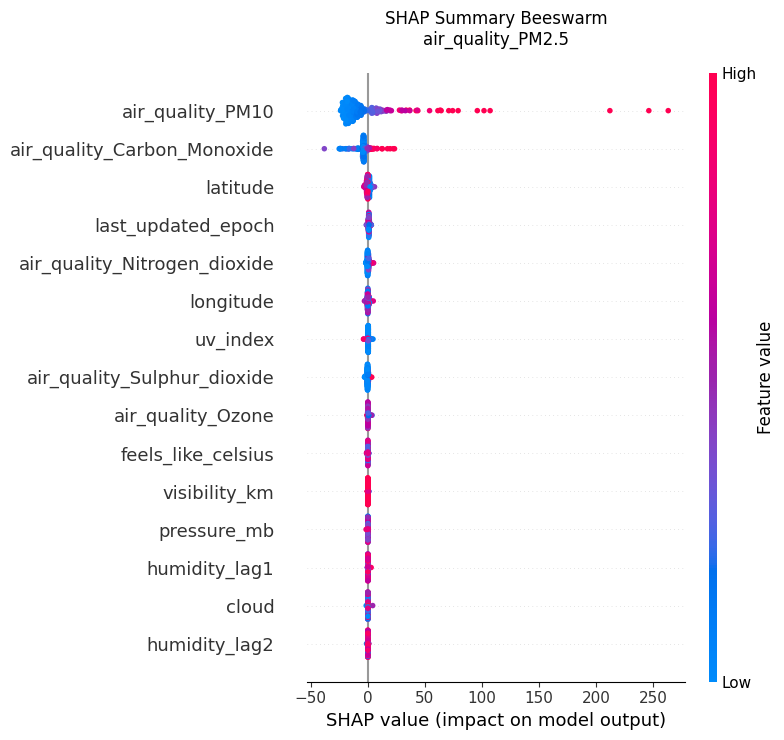

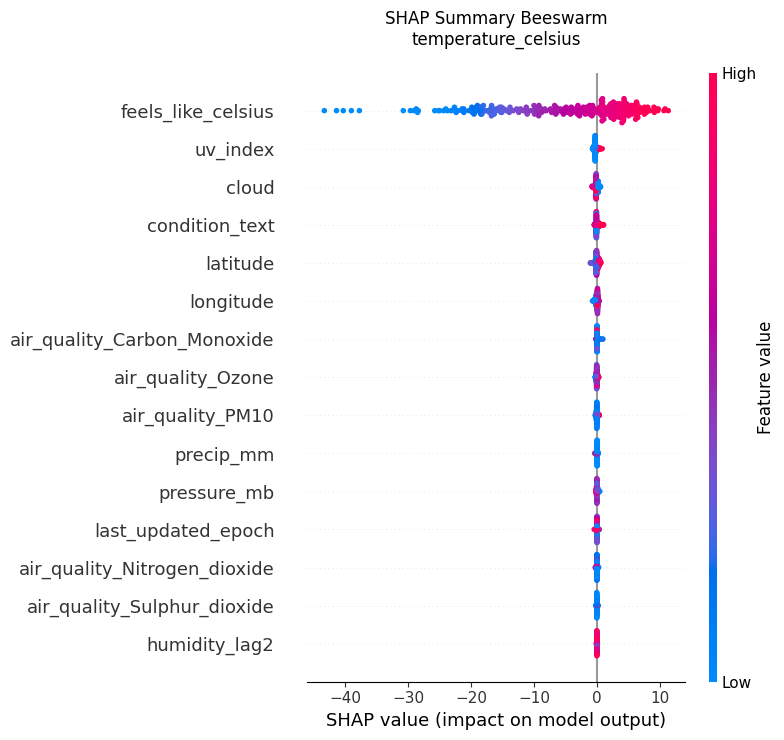

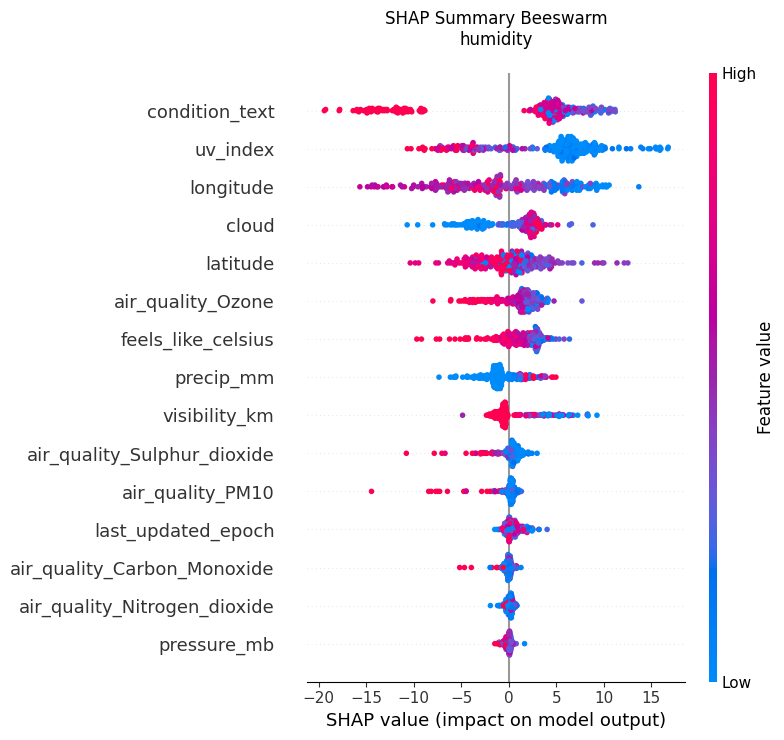

In [32]:
# ============================================================
# SHAP SUMMARY BEESWARM - ALL TARGETS
# ============================================================

for target in targets:

    target_shap_values = (
        shap_results[target][
            "shap_values"
        ]
    )

    shap.summary_plot(
        target_shap_values,
        X_shap,
        max_display=15,
        show=False
    )

    plt.title(
        f"SHAP Summary Beeswarm\n{target}",
        pad=20
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/01_SHAP_Beeswarm_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

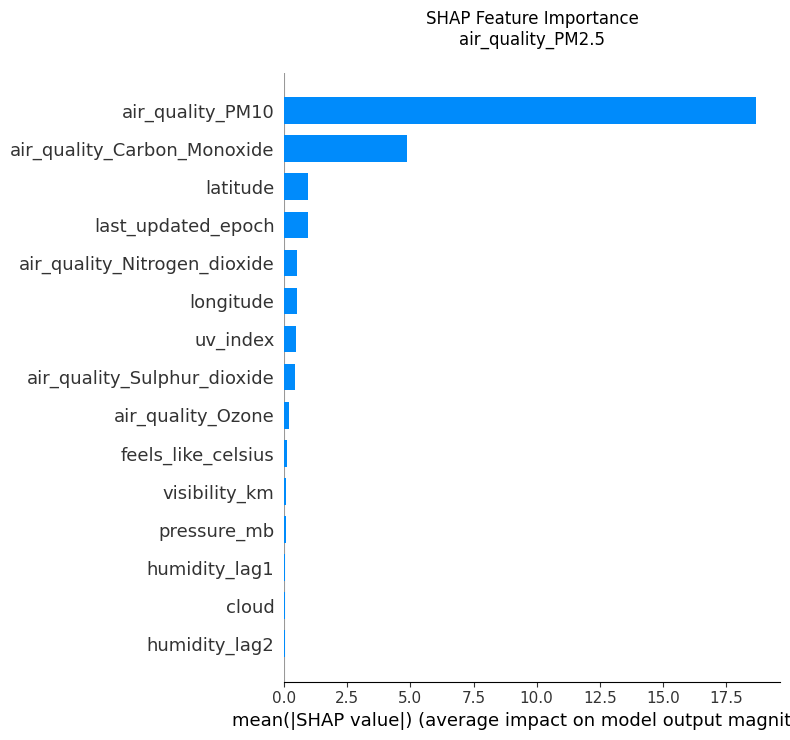

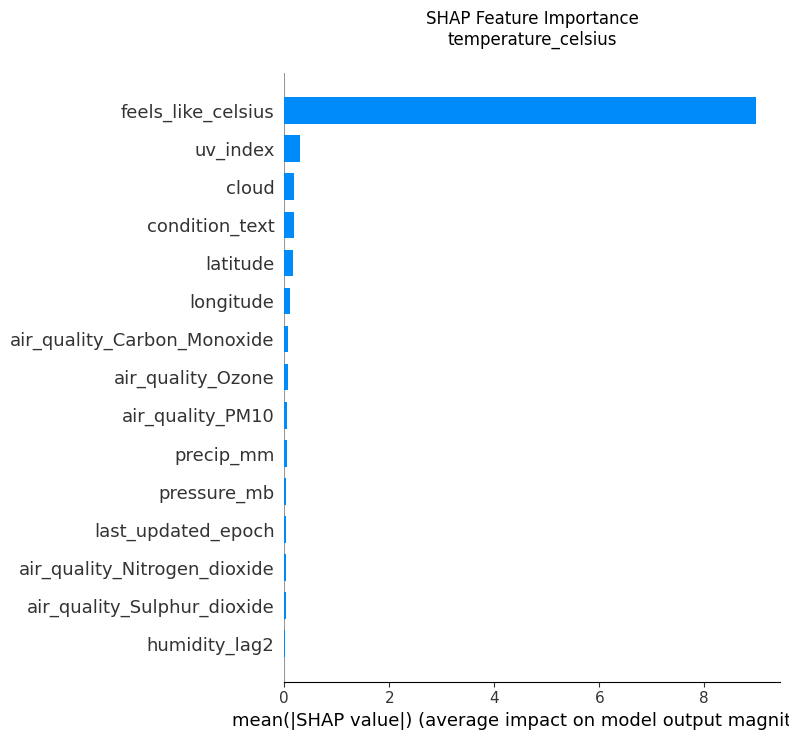

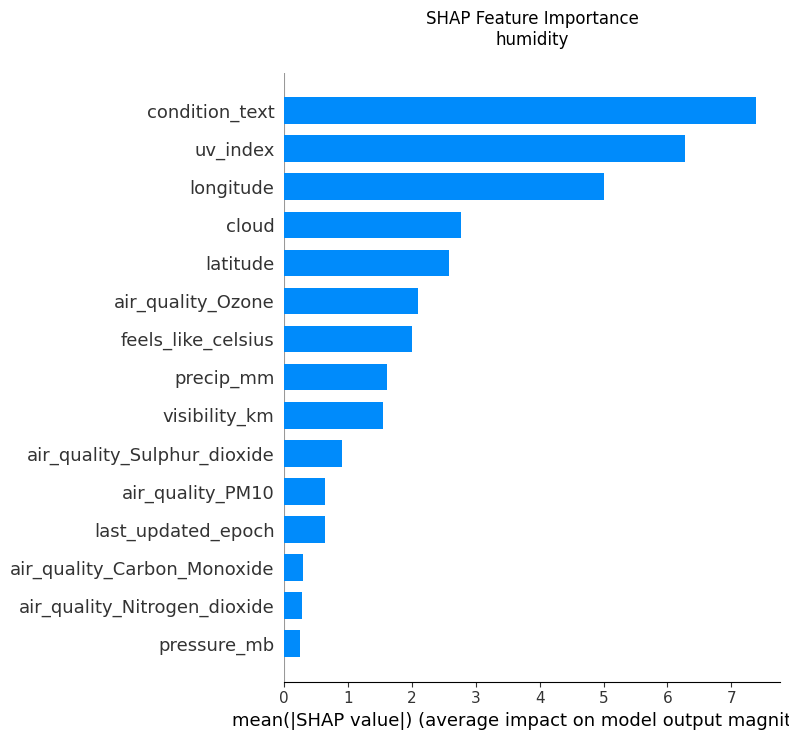

In [33]:
# ============================================================
# SHAP BAR PLOTS - ALL TARGETS
# ============================================================

for target in targets:

    target_shap_values = (
        shap_results[target][
            "shap_values"
        ]
    )

    shap.summary_plot(
        target_shap_values,
        X_shap,
        plot_type="bar",
        max_display=15,
        show=False
    )

    plt.title(
        f"SHAP Feature Importance\n{target}",
        pad=20
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/02_SHAP_Bar_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

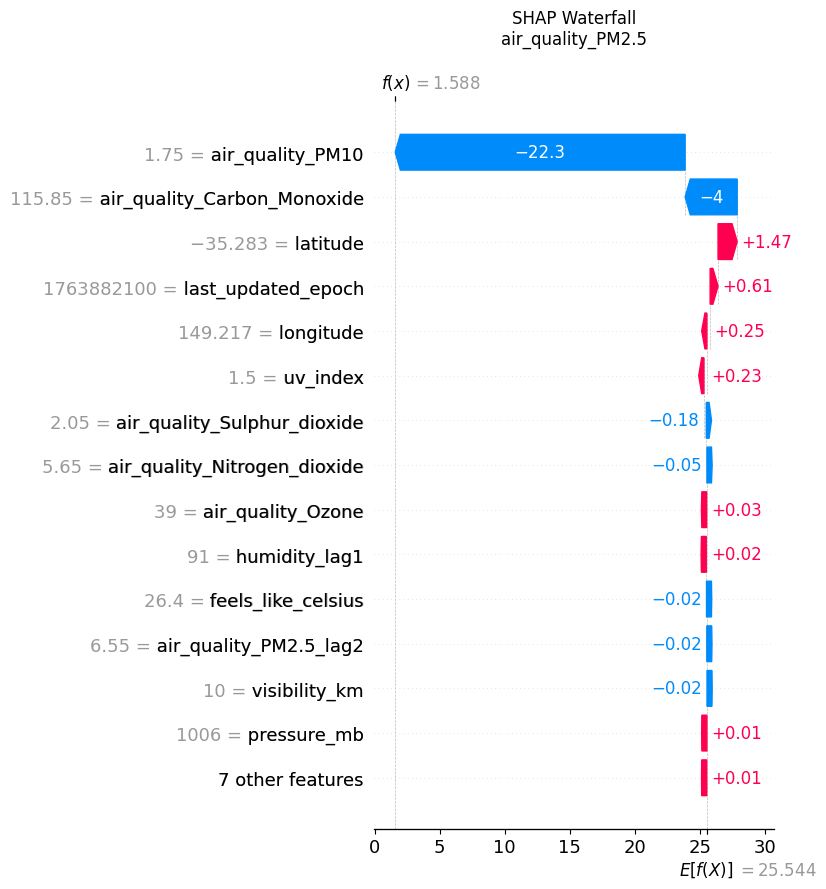

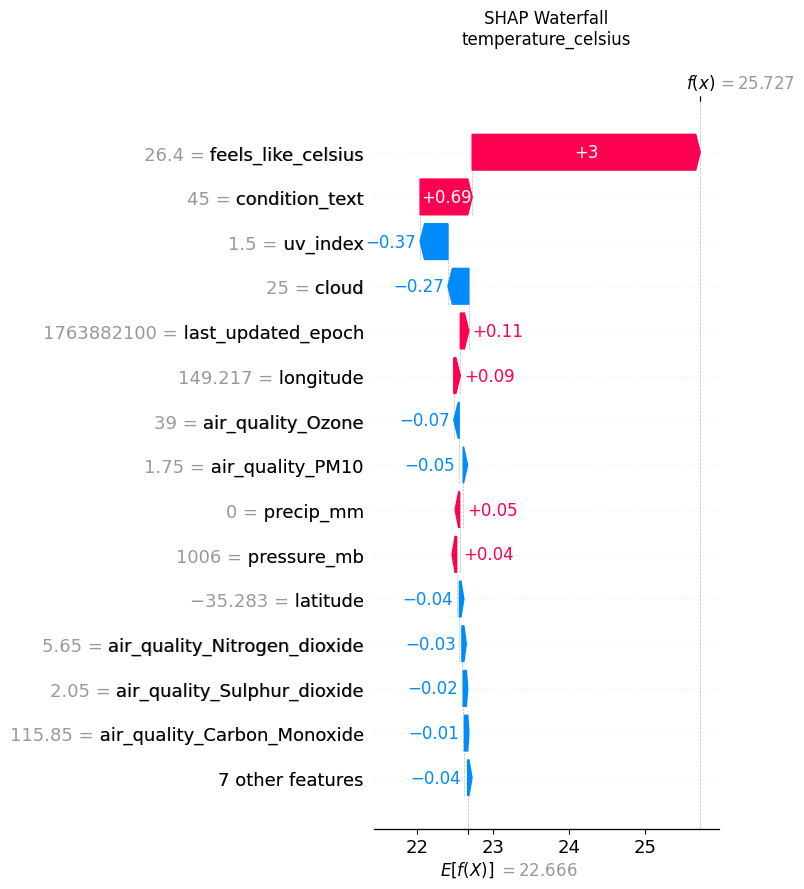

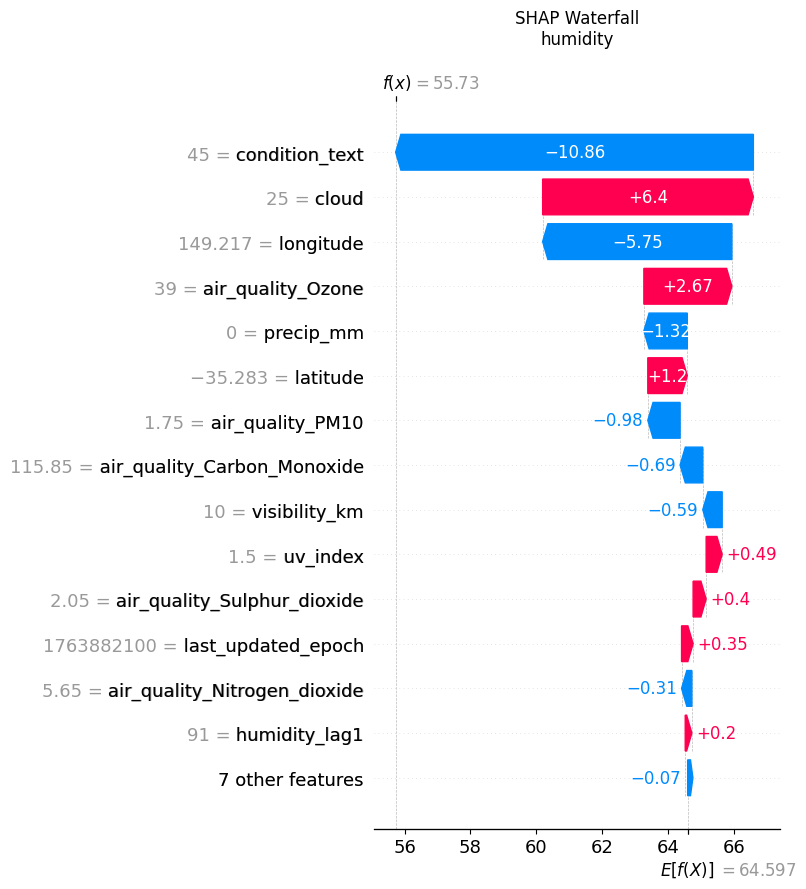

In [34]:
# ============================================================
# SHAP WATERFALL - ALL TARGETS
# ============================================================

WATERFALL_SAMPLE_INDEX = 0

for target in targets:

    target_explainer = (
        shap_results[target][
            "explainer"
        ]
    )

    target_shap_values = (
        shap_results[target][
            "shap_values"
        ]
    )

    base_value = (
        target_explainer.expected_value
    )

    base_value = float(
        np.asarray(base_value)
        .reshape(-1)[0]
    )

    waterfall_explanation = shap.Explanation(
        values=target_shap_values[
            WATERFALL_SAMPLE_INDEX
        ],
        base_values=base_value,
        data=X_shap.iloc[
            WATERFALL_SAMPLE_INDEX
        ].to_numpy(),
        feature_names=X_shap.columns.tolist()
    )

    shap.plots.waterfall(
        waterfall_explanation,
        max_display=15,
        show=False
    )

    plt.title(
        f"SHAP Waterfall\n{target}",
        pad=20
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/03_SHAP_Waterfall_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


Top 3 features for air_quality_PM2.5: ['air_quality_PM10', 'air_quality_Carbon_Monoxide', 'latitude']


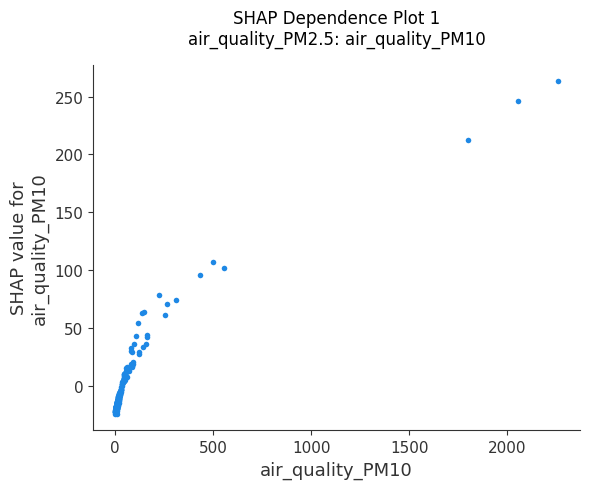

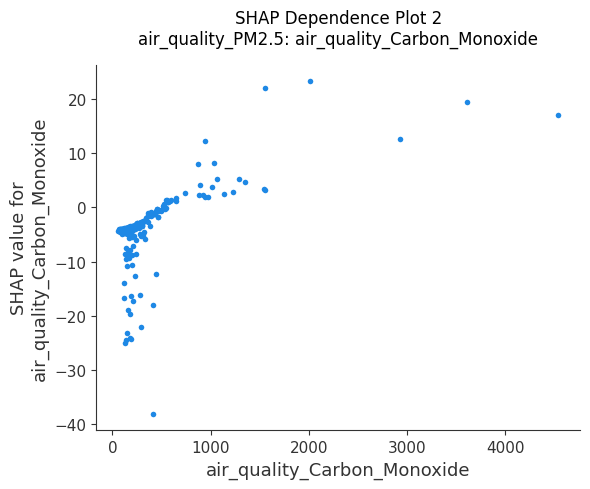

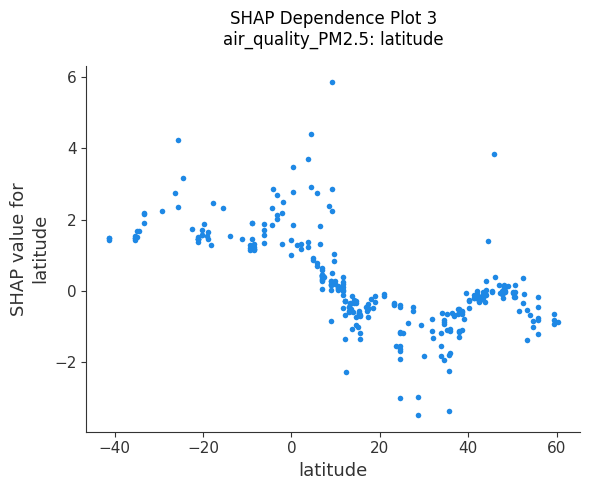


Top 3 features for temperature_celsius: ['feels_like_celsius', 'uv_index', 'cloud']


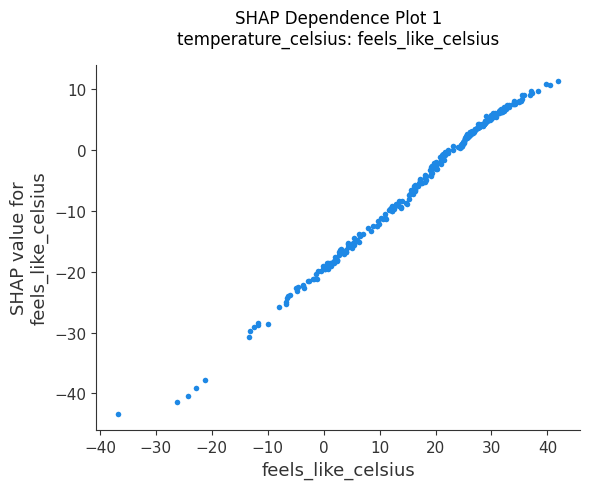

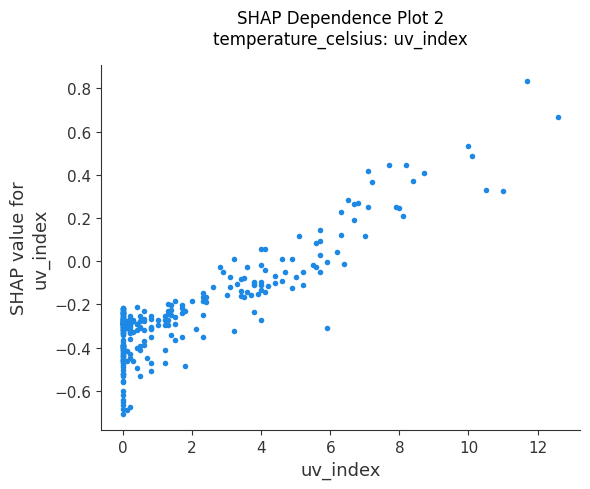

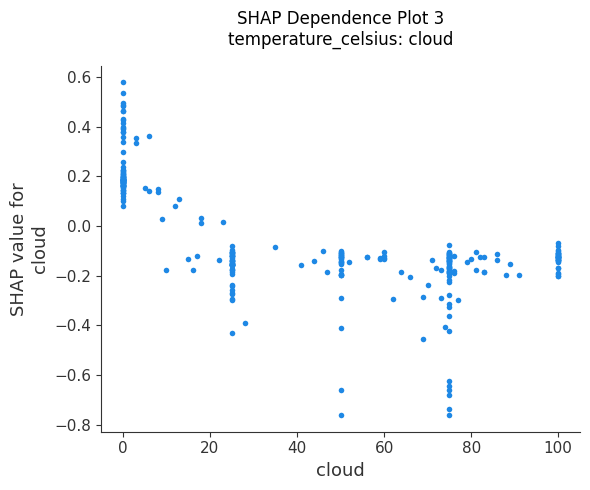


Top 3 features for humidity: ['condition_text', 'uv_index', 'longitude']


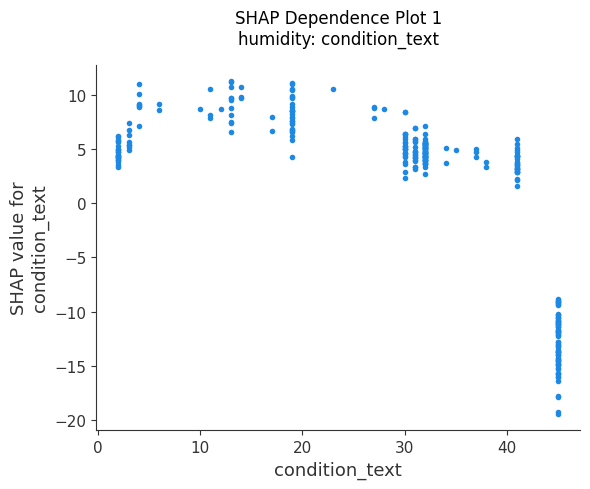

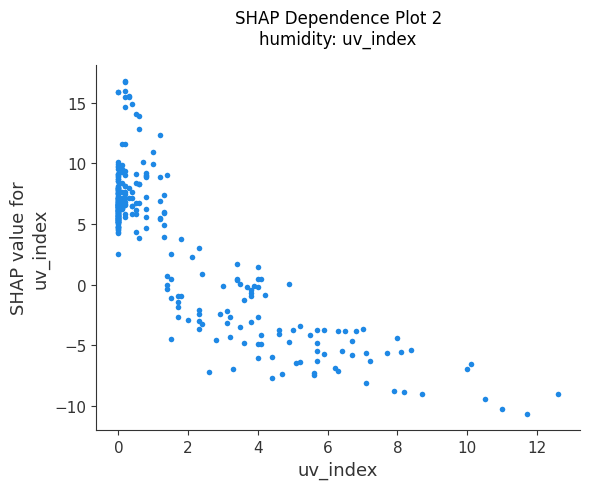

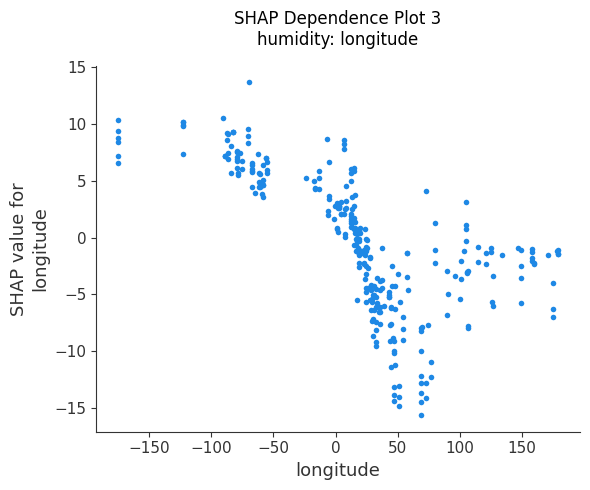

In [35]:
# ============================================================
# TOP 3 SHAP DEPENDENCE PLOTS - ALL TARGETS
# ============================================================

for target in targets:

    target_shap_values = (
        shap_results[target][
            "shap_values"
        ]
    )

    importance_df = (
        shap_results[target][
            "importance"
        ]
    )

    top3_features = (
        importance_df["Feature"]
        .head(3)
        .tolist()
    )

    print(
        f"\nTop 3 features for {target}:",
        top3_features
    )

    for feature_position, feature in enumerate(
        top3_features,
        start=1
    ):

        shap.dependence_plot(
            feature,
            target_shap_values,
            X_shap,
            interaction_index=None,
            show=False
        )

        plt.title(
            f"SHAP Dependence Plot {feature_position}\n"
            f"{target}: {feature}",
            pad=15
        )

        plt.tight_layout()

        plt.savefig(
            f"{save_dir}/04_{feature_position}_"
            f"SHAP_Dependence_"
            f"{safe_name(target)}_"
            f"{safe_name(feature)}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

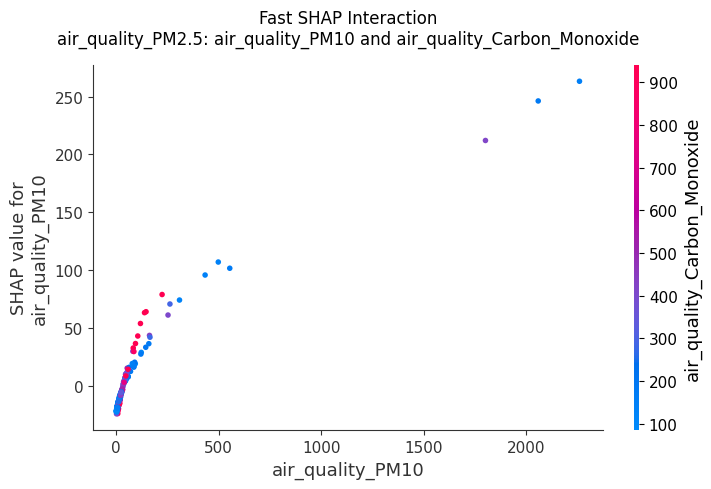

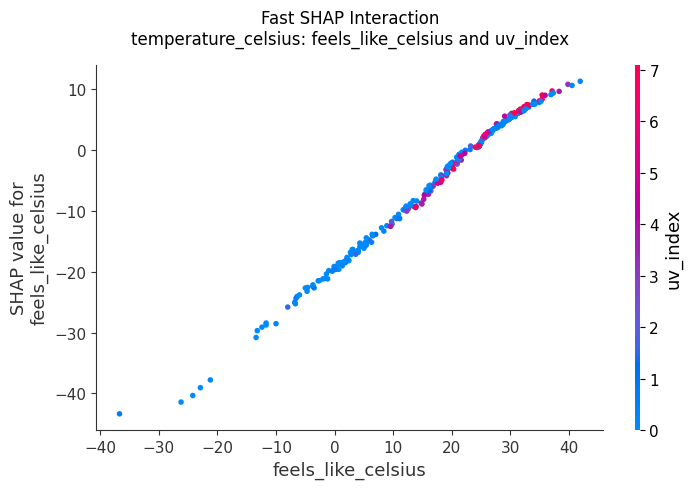

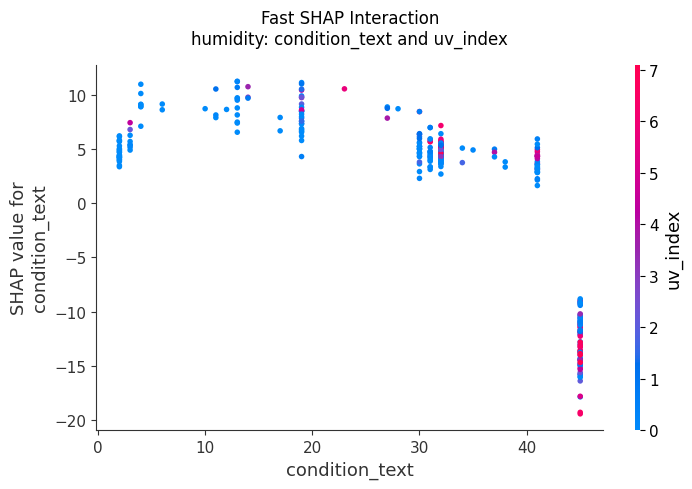

In [36]:
# ============================================================
# FAST SHAP INTERACTION PLOTS
# ============================================================

for target in targets:

    target_shap_values = (
        shap_results[target][
            "shap_values"
        ]
    )

    importance_df = (
        shap_results[target][
            "importance"
        ]
    )

    top2_features = (
        importance_df["Feature"]
        .head(2)
        .tolist()
    )

    feature1 = top2_features[0]
    feature2 = top2_features[1]

    shap.dependence_plot(
        feature1,
        target_shap_values,
        X_shap,
        interaction_index=feature2,
        show=False
    )

    plt.title(
        f"Fast SHAP Interaction\n"
        f"{target}: {feature1} and {feature2}",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/05_SHAP_Interaction_"
        f"{safe_name(target)}_"
        f"{safe_name(feature1)}_"
        f"{safe_name(feature2)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

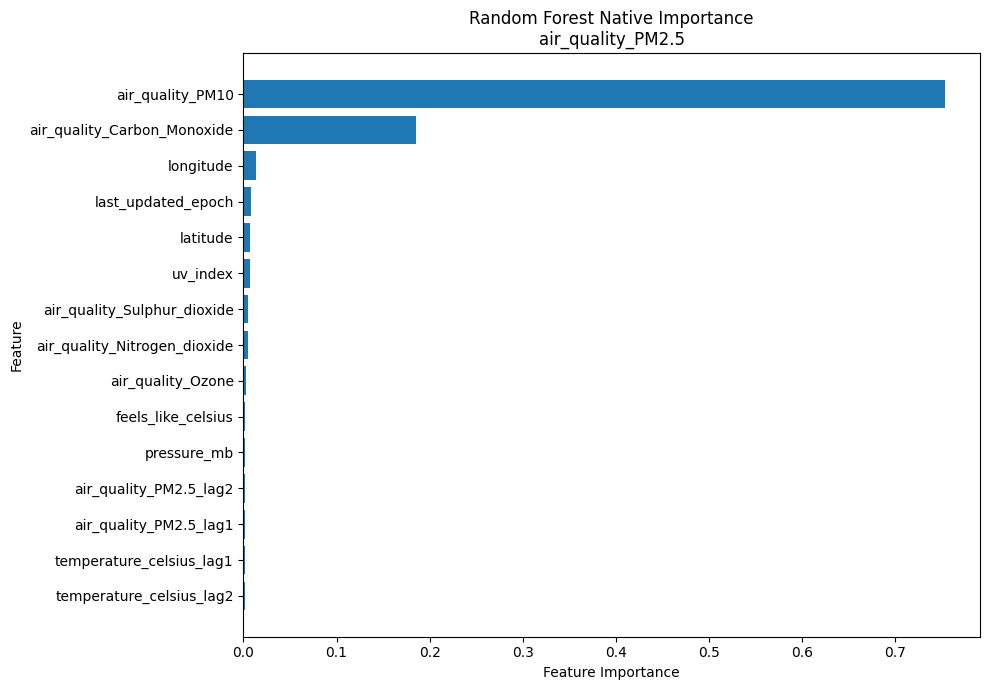

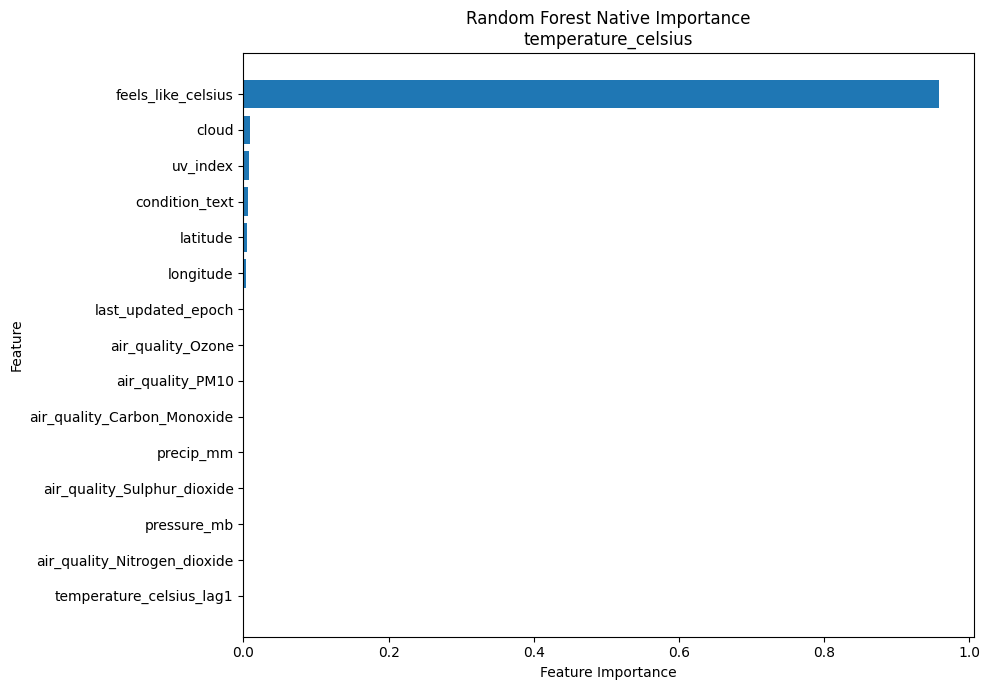

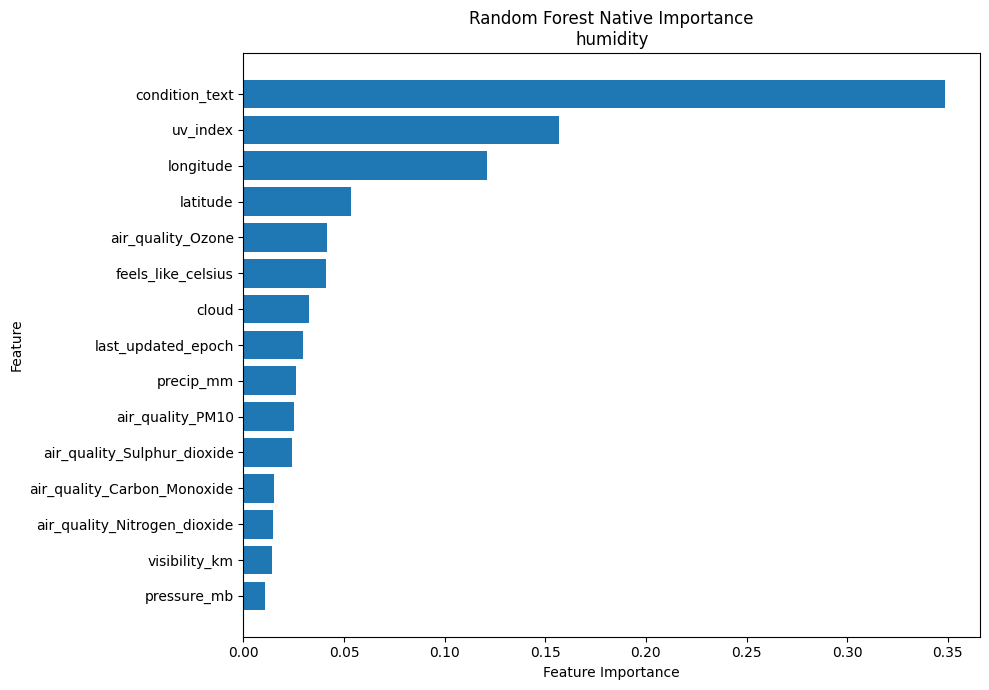

In [37]:
# ============================================================
# NATIVE RF FEATURE IMPORTANCE - ALL TARGETS
# ============================================================

native_importance_tables = []

for target_index, target in enumerate(targets):

    target_forest = (
        rf_multi_model.estimators_[
            target_index
        ]
    )

    native_df = pd.DataFrame({
        "Target": target,
        "Feature": X_test.columns,
        "RF_Importance":
            target_forest.feature_importances_
    }).sort_values(
        "RF_Importance",
        ascending=False
    ).reset_index(drop=True)

    native_importance_tables.append(
        native_df
    )

    native_df.to_csv(
        f"{save_dir}/RF_Native_Importance_"
        f"{safe_name(target)}.csv",
        index=False
    )

    top_native = native_df.head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_native["Feature"][::-1],
        top_native["RF_Importance"][::-1]
    )

    plt.title(
        f"Random Forest Native Importance\n{target}"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/06_RF_Native_Importance_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

all_native_importance_df = pd.concat(
    native_importance_tables,
    ignore_index=True
)

all_native_importance_df.to_csv(
    f"{save_dir}/RF_Native_Importance_All_Targets.csv",
    index=False
)

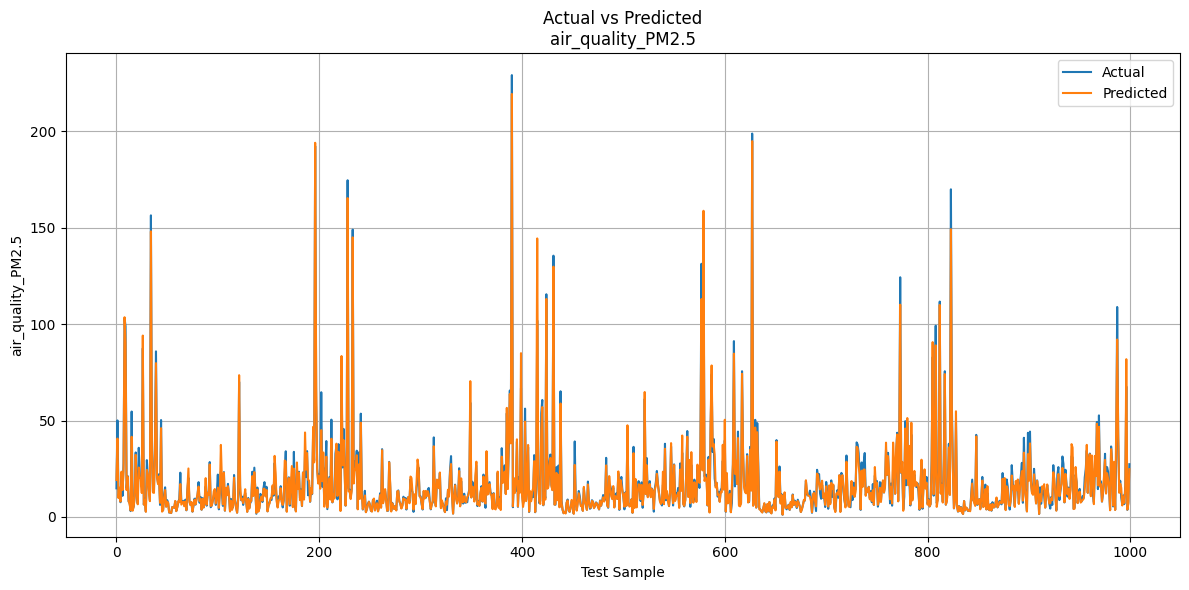

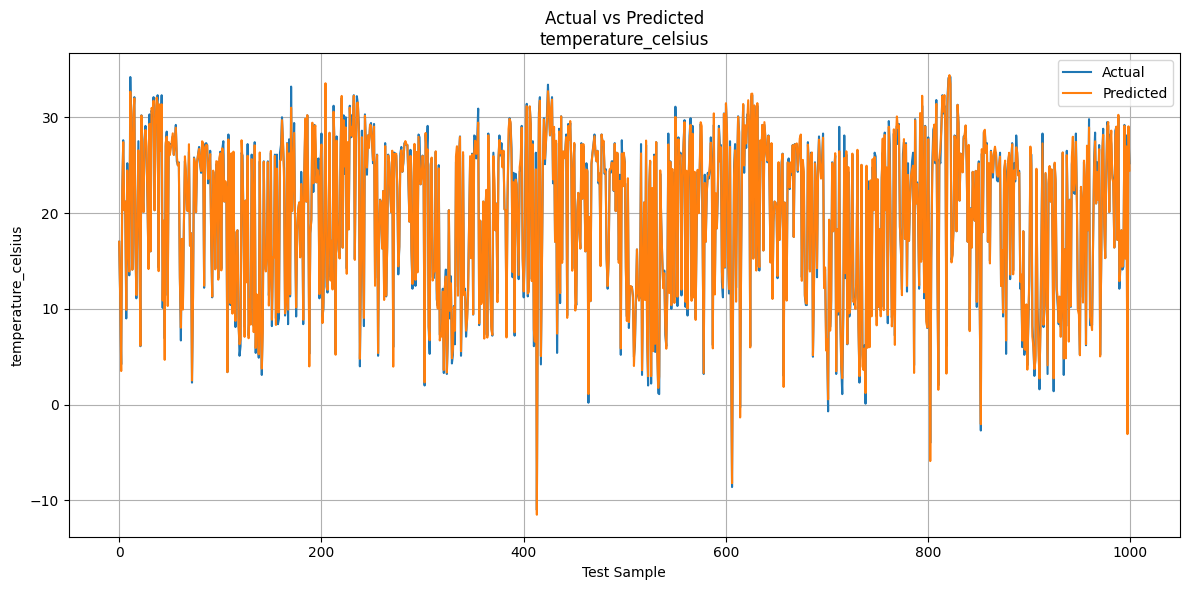

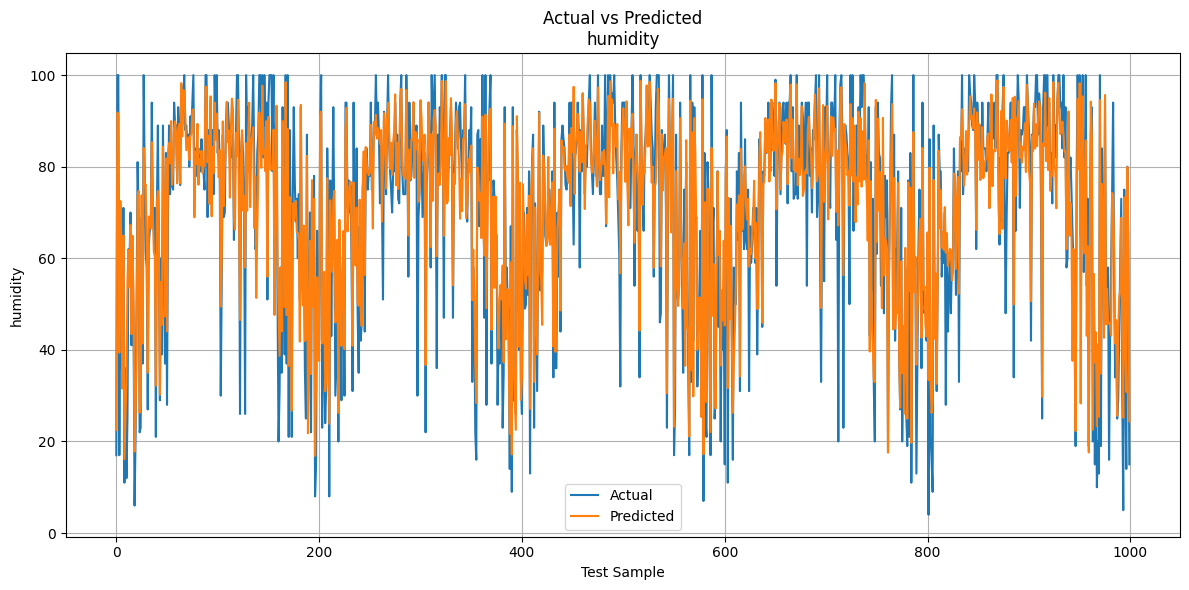

In [38]:
# ============================================================
# ACTUAL VS PREDICTED - ALL TARGETS
# ============================================================

PLOT_SAMPLE_COUNT = min(
    1000,
    len(y_test_df)
)

for target_index, target in enumerate(targets):

    y_actual = (
        y_test_df[target]
        .to_numpy(dtype=float)
    )

    y_predicted = (
        test_predictions[:, target_index]
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        y_actual[:PLOT_SAMPLE_COUNT],
        label="Actual"
    )

    plt.plot(
        y_predicted[:PLOT_SAMPLE_COUNT],
        label="Predicted"
    )

    plt.title(
        f"Actual vs Predicted\n{target}"
    )

    plt.xlabel("Test Sample")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/07_Actual_vs_Predicted_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

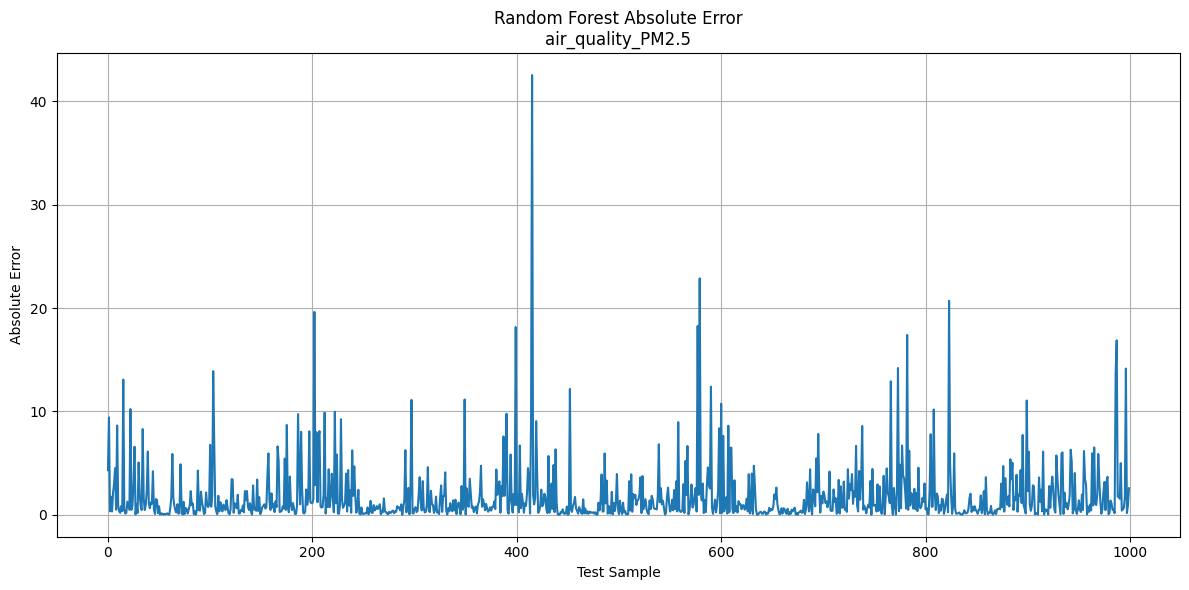

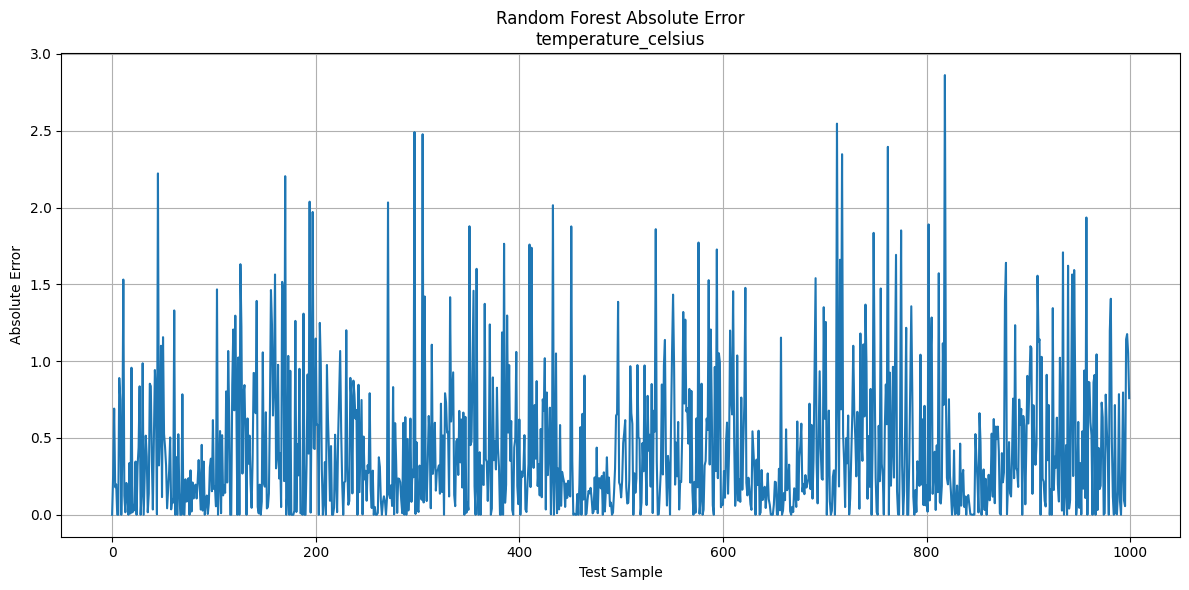

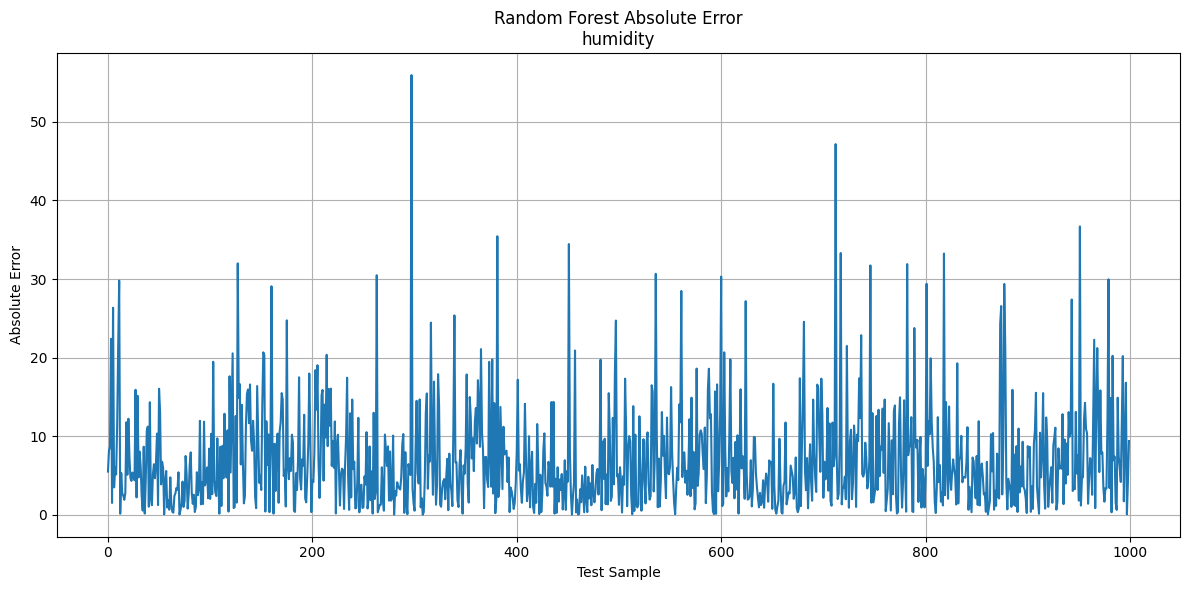

In [39]:
# ============================================================
# ABSOLUTE ERROR - ALL TARGETS
# ============================================================

for target_index, target in enumerate(targets):

    y_actual = (
        y_test_df[target]
        .to_numpy(dtype=float)
    )

    y_predicted = (
        test_predictions[:, target_index]
    )

    absolute_error = np.abs(
        y_actual - y_predicted
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        absolute_error[:PLOT_SAMPLE_COUNT]
    )

    plt.title(
        f"Random Forest Absolute Error\n{target}"
    )

    plt.xlabel("Test Sample")
    plt.ylabel("Absolute Error")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/08_Absolute_Error_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

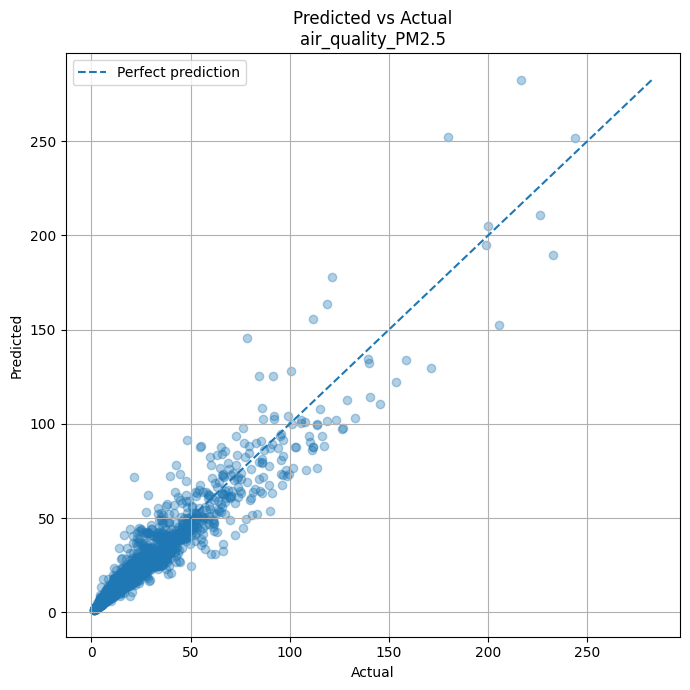

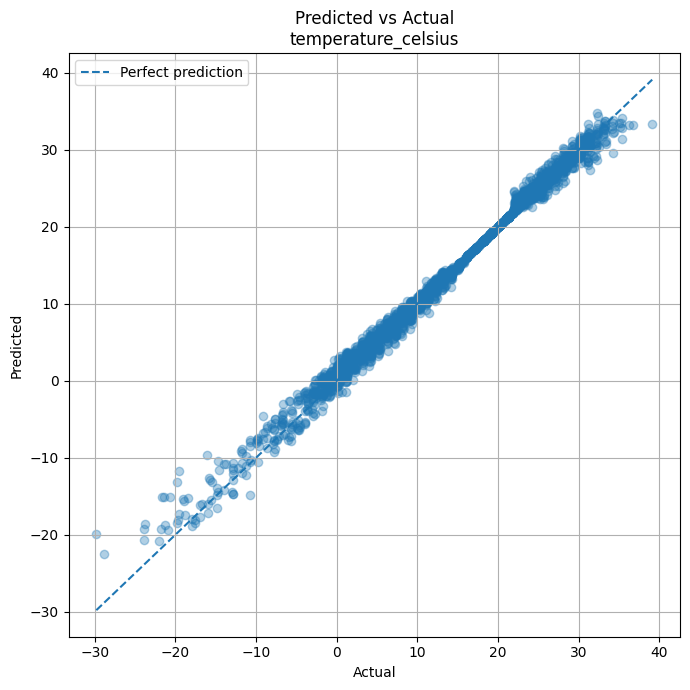

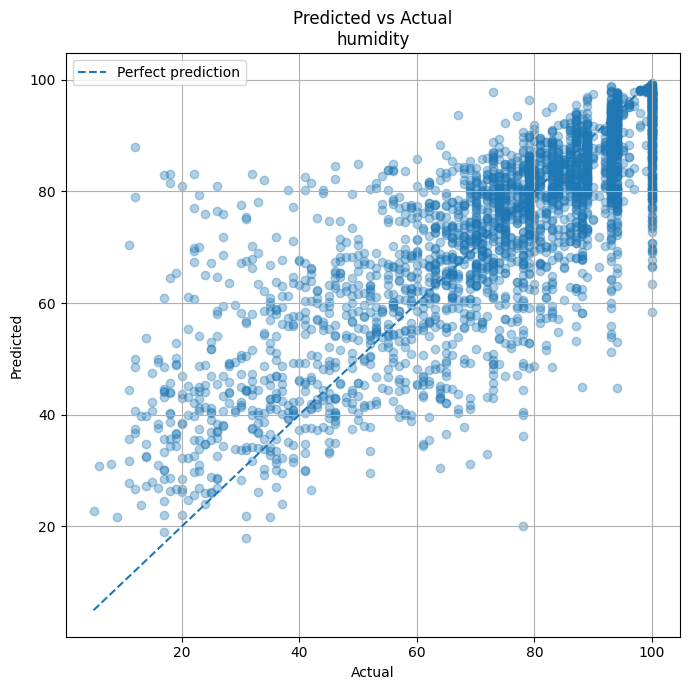

In [40]:
# ============================================================
# PREDICTED VS ACTUAL SCATTER - ALL TARGETS
# ============================================================

SCATTER_SAMPLE_SIZE = min(
    3000,
    len(y_test_df)
)

rng = np.random.default_rng(42)

scatter_indices = rng.choice(
    len(y_test_df),
    size=SCATTER_SAMPLE_SIZE,
    replace=False
)

for target_index, target in enumerate(targets):

    y_actual = (
        y_test_df[target]
        .to_numpy(dtype=float)
    )[scatter_indices]

    y_predicted = (
        test_predictions[:, target_index]
    )[scatter_indices]

    minimum = min(
        y_actual.min(),
        y_predicted.min()
    )

    maximum = max(
        y_actual.max(),
        y_predicted.max()
    )

    plt.figure(figsize=(7, 7))

    plt.scatter(
        y_actual,
        y_predicted,
        alpha=0.35
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect prediction"
    )

    plt.title(
        f"Predicted vs Actual\n{target}"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/09_Predicted_vs_Actual_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

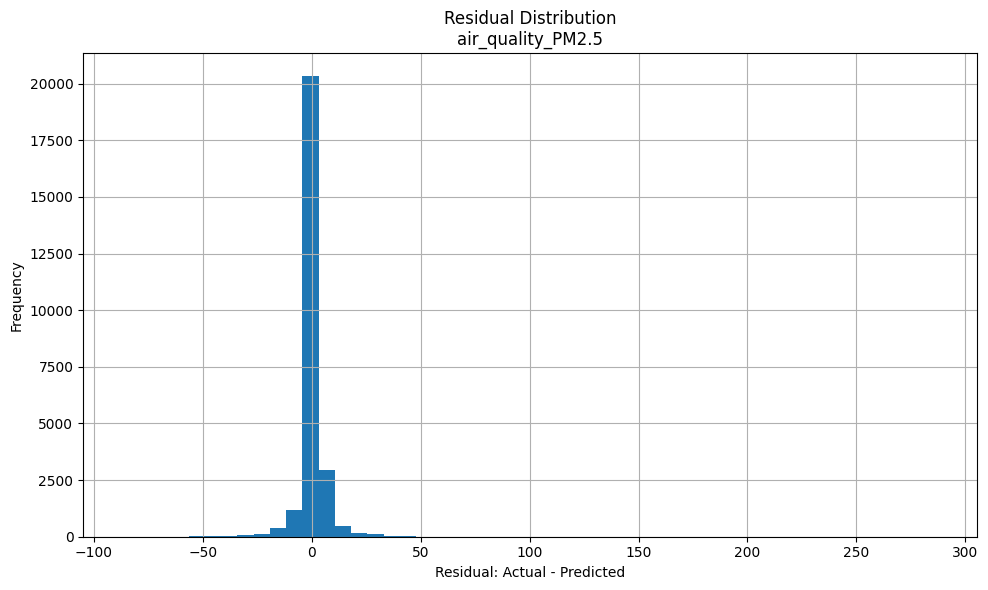

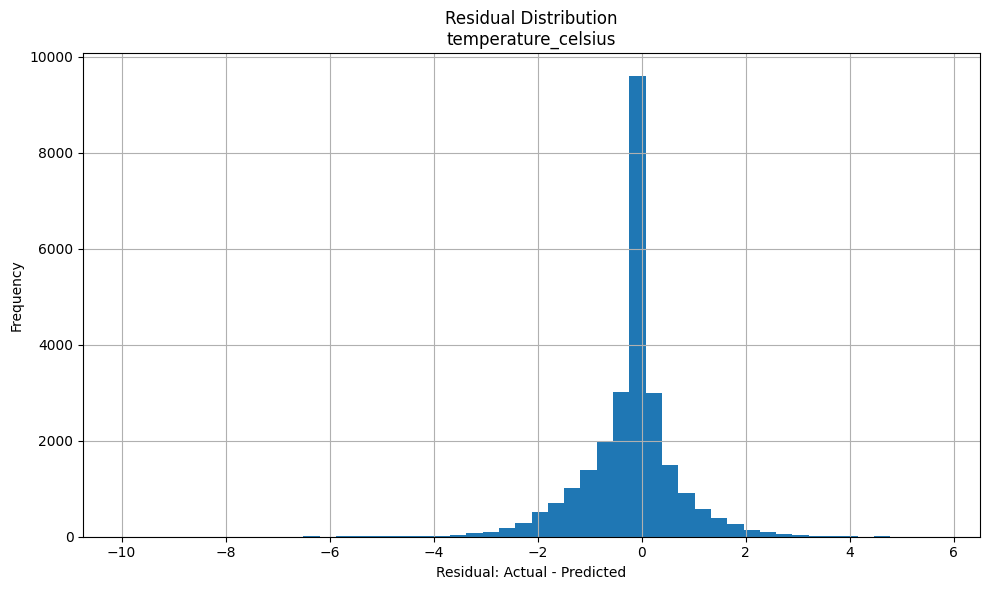

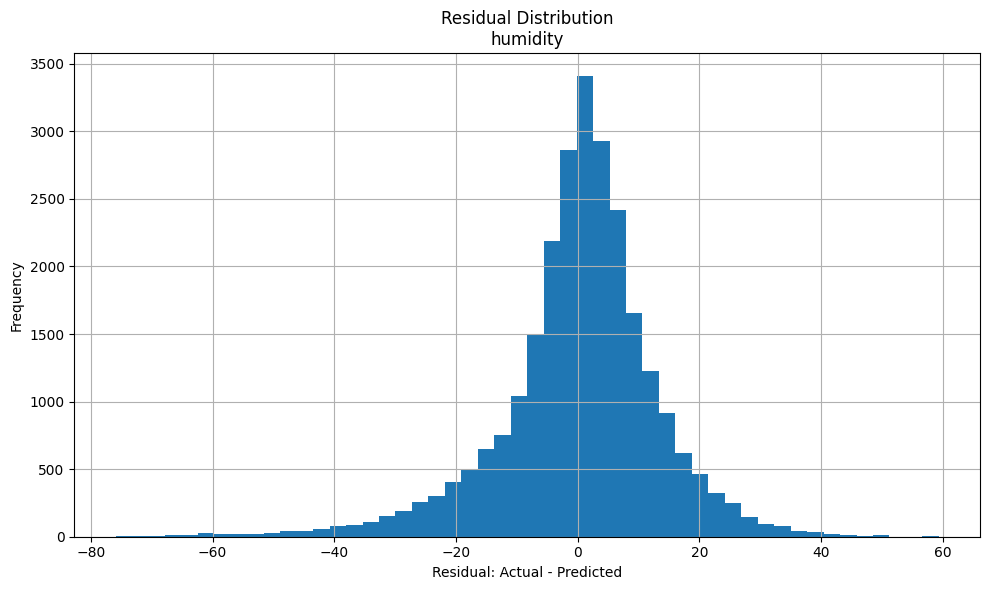

In [41]:
# ============================================================
# RESIDUAL DISTRIBUTION - ALL TARGETS
# ============================================================

for target_index, target in enumerate(targets):

    y_actual = (
        y_test_df[target]
        .to_numpy(dtype=float)
    )

    y_predicted = (
        test_predictions[:, target_index]
    )

    residuals = (
        y_actual - y_predicted
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        residuals,
        bins=50
    )

    plt.title(
        f"Residual Distribution\n{target}"
    )

    plt.xlabel("Residual: Actual - Predicted")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"{save_dir}/10_Residual_Distribution_"
        f"{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [42]:
# ============================================================
# COMBINED SHAP IMPORTANCE AND RANK TABLE
# ============================================================

combined_shap_tables = []

for target in targets:

    target_table = (
        shap_results[target][
            "importance"
        ].copy()
    )

    target_table.insert(
        0,
        "Target",
        target
    )

    target_table["Importance_Rank"] = (
        target_table[
            "Mean_Absolute_SHAP"
        ]
        .rank(
            method="dense",
            ascending=False
        )
        .astype(int)
    )

    combined_shap_tables.append(
        target_table
    )

combined_shap_importance_df = pd.concat(
    combined_shap_tables,
    ignore_index=True
)

combined_shap_importance_df.to_csv(
    f"{save_dir}/Combined_SHAP_Importance_All_Targets.csv",
    index=False
)

display(
    combined_shap_importance_df
    .sort_values(
        ["Target", "Importance_Rank"]
    )
    .head(30)
)

,Target,Feature,Mean_Absolute_SHAP,Importance_Rank
0,air_quality_PM2.5,air_quality_PM10,18.708229,1
1,air_quality_PM2.5,air_quality_Carbon_Monoxide,4.878847,2
2,air_quality_PM2.5,latitude,0.957670,3
3,air_quality_PM2.5,last_updated_epoch,0.923497,4
4,air_quality_PM2.5,air_quality_Nitrogen_dioxide,0.524632,5
5,air_quality_PM2.5,longitude,0.523403,6
6,air_quality_PM2.5,uv_index,0.457704,7
7,air_quality_PM2.5,air_quality_Sulphur_dioxide,0.420427,8
8,air_quality_PM2.5,air_quality_Ozone,0.194761,9
9,air_quality_PM2.5,feels_like_celsius,0.111125,10


In [43]:
# ============================================================
# SAVE FITTED MULTI-TARGET RANDOM FOREST
# ============================================================

import joblib

joblib.dump(
    rf_multi_model,
    f"{save_dir}/Multi_Target_Random_Forest_Model.joblib"
)

print("Model saved.")

Model saved.


In [44]:
# ============================================================
# ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

zip_path = (
    "/content/"
    "Multi_Target_RF_SHAP_Fast_Outputs.zip"
)

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for root, directories, filenames in os.walk(
        save_dir
    ):

        for filename in filenames:

            file_path = os.path.join(
                root,
                filename
            )

            archive_name = os.path.relpath(
                file_path,
                save_dir
            )

            zip_file.write(
                file_path,
                arcname=archive_name
            )

print("ZIP created successfully:")
print(zip_path)

files.download(zip_path)

ZIP created successfully:
/content/Multi_Target_RF_SHAP_Fast_Outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>